# 05 — Cross-soil analysis

**Question:** How does soil texture shift the tree-crop yield difference?

**Design:** Same structure as `fig_mechanisms` — bar chart with IQR error bars. One bar per soil texture, all else held constant:
- Tree: lf=1.0 (evergreen), Zr=1500 mm, T_MAX=2.0 (worst-case phenology — same as fig_mechanisms)
- Mechanisms: full system (deep roots + HR + shade)
- Climate: baseline, ~450 mm/season (α=10, λ=0.25)
- N=200 paired seasons

Textures span coarse → fine (Clapp & Hornberger 1978). The current default is **loam**; the published Krell model uses **clay loam**.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import nbformat

# Load class definitions from tree.ipynb
_nb = nbformat.read('../tree.ipynb', as_version=4)
for _cell in _nb.cells:
    if _cell.cell_type == 'code' and _cell.get('id', '') in {
        'c23f275b',   # core imports
        '9adc45cd',   # Tree class
        '2149719d',   # shade_factor()
        '3bed3936',   # TreeCropModel
        '6jrb65spyt', # _m_yield, _b_yield
        'b2d38c76',   # run_one_season, season_metrics, _tree_sf
    }:
        src = _cell['source'].replace("'data/", "'../data/").replace('"data/', '"../data/')
        exec(src, globals())

def despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

print('Setup complete.')

/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


Setup complete.


In [2]:
def _dY_soil(tree_params, climate_obj, seeds, texture, hr_max=1.0, **run_kwargs):
    """Paired ΔY simulations for a given soil texture.
    Mirrors _dY_array but accepts texture as an argument.
    """
    sf_ = _tree_sf(tree_params)
    lgp = 180
    out = []
    for seed in seeds:
        np.random.seed(seed)
        climate_obj.rainfall = Climate.generate(climate_obj.alpha_r, climate_obj.lambda_r)

        # monoculture
        s_m = Soil(texture=texture)
        c_m = Crop(soil=s_m)
        c_m.lgp = lgp
        s_m.set_nZr(c_m)
        m_m = CropModel(crop=c_m, climate=climate_obj, soil=s_m)
        m_m.run()
        _, _, y_m, _ = season_metrics(c_m, m_m.output(), lgp)

        # tree-crop
        s_t = Soil(texture=texture)
        c_t = Crop(soil=s_t)
        c_t.lgp = lgp
        tr_ = Tree(soil=s_t, **tree_params)
        m_t = TreeCropModel(crop=c_t, tree=tr_, climate=climate_obj, soil=s_t, hr_max=hr_max)
        m_t.run(**run_kwargs)
        _, _, y_t, _ = season_metrics(c_t, m_t.output(), lgp, sf=sf_)

        out.append(y_t - y_m)
    return np.array(out)

print('Helper ready.')

Helper ready.


In [3]:
N = 200
seeds = np.arange(N)
climate = Climate()  # baseline: α=10, λ=0.25, ~450 mm/season

# Same tree as fig_mechanisms: evergreen, deep-rooted, worst-case phenology
tp = dict(
    Zr=1500, T_MAX=2.0, kc=1.0, canopy_cover=0.2,
    sw_MPa=-2.0, s_star_MPa=-0.1, leaf_fraction=1.0,
)

# Textures: coarse → fine
TEXTURES = ['sand', 'sandy loam', 'loam', 'clay loam', 'clay']

results = {}
for texture in TEXTURES:
    arr = _dY_soil(tp, climate, seeds, texture=texture,
                  shade_on=True, hr_on=True, deep_roots=True)
    results[texture] = arr
    print(f'{texture:18s}  median={np.median(arr):+6.0f}  '
          f'IQR=[{np.percentile(arr,25):+.0f}, {np.percentile(arr,75):+.0f}]')

sand                median=   +61  IQR=[+45, +87]
sandy loam          median=   +77  IQR=[+41, +115]
loam                median=  +102  IQR=[+54, +191]
clay loam           median=  +116  IQR=[+0, +366]
clay                median=   +73  IQR=[+0, +255]


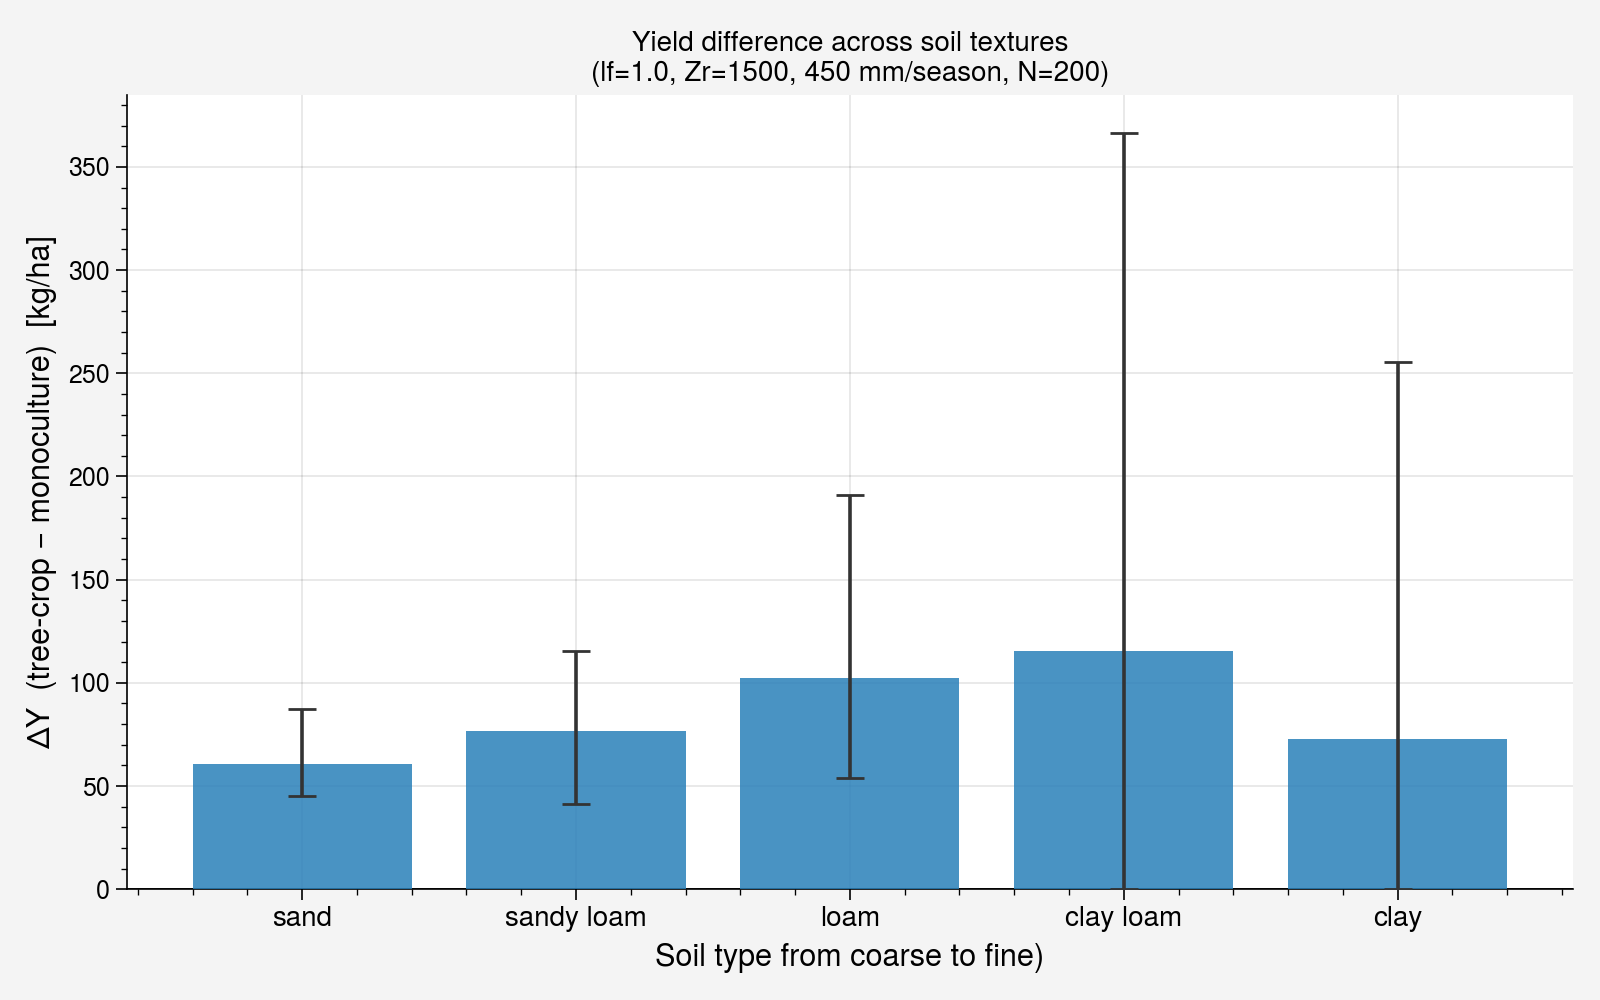

In [9]:
labels  = TEXTURES
medians = [np.median(results[t]) for t in TEXTURES]
q25     = [np.percentile(results[t], 25) for t in TEXTURES]
q75     = [np.percentile(results[t], 75) for t in TEXTURES]
yerr_lo = [m - lo for m, lo in zip(medians, q25)]
yerr_hi = [hi - m for m, hi in zip(medians, q75)]

# Highlight the two reference textures
colors = []
for t in TEXTURES:
    if t == 'loam':
        colors.append('#2980b9')   # blue — current tree notebook default
    elif t == 'clay loam':
        colors.append('#2980b9')   # green — published Krell model
    else:
        colors.append('#2980b9')   # grey

x = np.arange(len(TEXTURES))
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x, medians, color=colors, alpha=0.85, zorder=3,
       yerr=[yerr_lo, yerr_hi],
       error_kw=dict(ecolor='#333333', capsize=5, lw=1.3))
ax.axhline(0, color='k', lw=1.0, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('ΔY  (tree-crop − monoculture)  [kg/ha]', fontsize=11)
ax.set_xlabel('Soil type from coarse to fine)', fontsize=11)
ax.set_title(
    'Yield difference across soil textures\n'
    f'(lf=1.0, Zr=1500, 450 mm/season, N={N})',
    fontsize=10
)

# Legend for reference textures
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2980b9', alpha=0.85, label='Loam (tree notebook default)'),
    Patch(facecolor='#2980b9', alpha=0.85, label='Clay loam (Krell model)'),
    Patch(facecolor='#2980b9', alpha=0.85, label='Other textures'),
]
# ax.legend(handles=legend_elements, fontsize=8, frameon=False)
# ax.text(0.98, 0.02, 'Bars: median  |  Error bars: IQR',
        # transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='#666666')

despine(ax)
plt.tight_layout()
plt.savefig('../output/fig7_cross_soils.png', dpi=150, bbox_inches='tight')
plt.show()